In [1]:
!which python

/home/midori/Desktop/Machine-Learning/venv/bin/python


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, classification_report

#### Load Dataset

In [3]:
# as_frame = False returns numpy array else True gives Dataframe
digits = load_digits() # 8*8 pixel in each images = 64 features

In [4]:
X = digits.data
Y = digits.target

In [ ]:
X[0] 
# Each number is a pixel intensity value.
# Brighter values = whiter pixels.
# Lower values = darker pixels.
# It’s just an 8×8 grayscale grid flattened.
# 

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

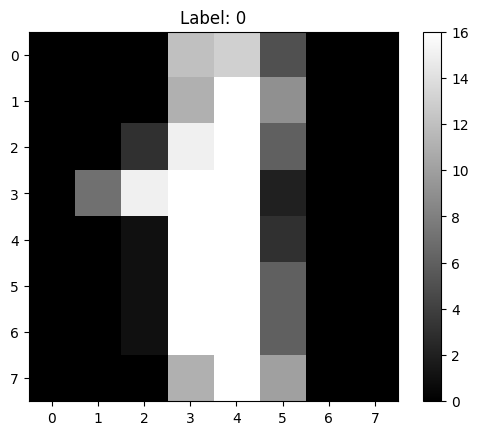

In [26]:
plt.imshow(X[1].reshape(8,8), cmap='gray')
plt.title(f"Label: {Y[0]}")
plt.colorbar()
plt.show()

In [23]:
X.shape

(1797, 64)

In [30]:
Y

array([0, 1, 2, ..., 8, 9, 8], shape=(1797,))

In [31]:
Y.shape

(1797,)

#### Test-Train split

In [35]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,
                                                 test_size=0.2,
                                                 random_state=2,
                                                 stratify=Y)

In [36]:
# Further split Training → Train + Validation
X_train,X_validate,Y_train,Y_validate = train_test_split(X_train,Y_train,
                                                         test_size=0.1,
                                                         stratify=Y_train,
                                                         random_state=2)

#### Standardize Features (SVM)

In [37]:
scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)
X_validate = scalar.transform(X_validate)
X_test = scalar.transform(X_test)

In [39]:
X_train[0]

array([ 0.        , -0.33385823, -0.88460513,  0.26874232, -0.43020032,
       -1.01889181, -0.41033644, -0.13279631, -0.05909681,  1.58077805,
        1.03333024,  1.010747  ,  1.1964405 , -0.19856383, -0.51807283,
       -0.13866821, -0.04546042,  1.49591722,  1.06736212,  1.05708873,
        0.46785495,  1.16324532, -0.5574111 , -0.1104749 , -0.03935971,
        1.76818978,  1.10757281, -1.14786383, -1.28116546,  1.27335899,
        0.186392  , -0.0557062 ,  0.        ,  0.72891731,  1.12828471,
       -1.14672261, -1.7401662 ,  0.57322358,  1.16422304,  0.        ,
       -0.05226026, -0.20371294,  1.21920841, -0.19189746, -0.89980364,
        1.36046896, -0.09475688, -0.08083231, -0.0342518 , -0.4058922 ,
        0.59698939,  1.04334016,  0.69315649,  1.21543016, -0.74727717,
       -0.20739512,  0.        , -0.29359316, -0.89484667,  0.65963369,
        0.43782761,  0.20382381, -0.50843028, -0.19385418])

#### Initialize Linear SVM (SGD-based)

In [41]:
svm = SGDClassifier(
    loss="hinge",          # Linear SVM
    max_iter=1,            # One epoch at a time
    learning_rate="optimal",
    random_state=2
)

In [ ]:
epochs = 10
train_acc = []
val_acc = []

classes = np.unique(Y_train)
# This extracts the set of distinct class labels present in y_train.
# partial_fit() must know all possible classes in advance.

In [43]:
classes

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

#### Training Loop (Manual 10 Epochs)

In [44]:
for epoch in range(epochs):
    
    # Shuffle training data each epoch
    indices = np.random.permutation(len(X_train))
    X_train_shuffled = X_train[indices]
    y_train_shuffled = Y_train[indices]

    svm.partial_fit(X_train_shuffled, y_train_shuffled, classes=classes)

    # Accuracy
    y_train_pred = svm.predict(X_train)
    y_val_pred = svm.predict(X_validate)

    train_acc.append(accuracy_score(Y_train, y_train_pred))
    val_acc.append(accuracy_score(Y_validate, y_val_pred))

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Acc: {train_acc[-1]:.4f} | "
          f"Val Acc: {val_acc[-1]:.4f}")

Epoch 1/10 | Train Acc: 0.9420 | Val Acc: 0.9306
Epoch 2/10 | Train Acc: 0.9582 | Val Acc: 0.9514
Epoch 3/10 | Train Acc: 0.9683 | Val Acc: 0.9375
Epoch 4/10 | Train Acc: 0.9737 | Val Acc: 0.9653
Epoch 5/10 | Train Acc: 0.9853 | Val Acc: 0.9792
Epoch 6/10 | Train Acc: 0.9884 | Val Acc: 0.9583
Epoch 7/10 | Train Acc: 0.9830 | Val Acc: 0.9514
Epoch 8/10 | Train Acc: 0.9869 | Val Acc: 0.9722
Epoch 9/10 | Train Acc: 0.9861 | Val Acc: 0.9653
Epoch 10/10 | Train Acc: 0.9907 | Val Acc: 0.9514


#### Final Evaluation on Test Set

In [45]:
y_test_pred = svm.predict(X_test)

print("\nFinal Test Accuracy:", accuracy_score(Y_test, y_test_pred))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(Y_test, y_test_pred))


Final Test Accuracy: 0.9388888888888889

Confusion Matrix:
 [[36  0  0  0  0  0  0  0  0  0]
 [ 0 34  0  1  0  0  0  0  1  0]
 [ 0  0 31  1  1  0  0  0  2  0]
 [ 0  0  0 34  0  2  0  0  1  0]
 [ 0  0  0  0 35  0  0  0  0  1]
 [ 0  0  0  0  0 36  0  0  0  1]
 [ 0  1  0  0  0  0 35  0  0  0]
 [ 0  0  0  0  1  0  0 34  1  0]
 [ 0  2  0  0  0  0  0  0 33  0]
 [ 0  0  0  3  0  1  0  0  2 30]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      0.94      0.93        36
           2       1.00      0.89      0.94        35
           3       0.87      0.92      0.89        37
           4       0.95      0.97      0.96        36
           5       0.92      0.97      0.95        37
           6       1.00      0.97      0.99        36
           7       1.00      0.94      0.97        36
           8       0.82      0.94      0.88        35
           9       0.94      0.83      0.8

#### Plot Accuracy Curves

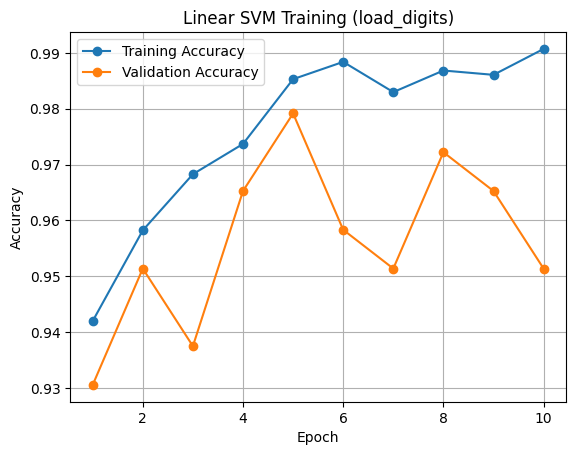

In [46]:
plt.figure()
plt.plot(range(1, epochs+1), train_acc, marker='o')
plt.plot(range(1, epochs+1), val_acc, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Linear SVM Training (load_digits)")
plt.legend(["Training Accuracy", "Validation Accuracy"])
plt.grid()
plt.show()